# Customer Segmentation

# Import Depedencies

In [1]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from random import sample
from numpy.random import uniform

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': '--', 
})

# Load Dataset

In [2]:
def route(path):
    for dirpath, _, filenames in os.walk('../../00-datasets'):
        if path in filenames:
            return os.path.join(dirpath, path)

name_file = 'Online_Retail.xlsx'

df = pd.read_excel(route(name_file))

print('Row x Column:', df.shape)
df.head()

Row x Column: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# Data Preprocessing

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [4]:
df['Quantity'] = df['Quantity'].abs()

df['Amount'] = df['Quantity'] * df['UnitPrice']
df['Date'] = df['InvoiceDate'].dt.date
df['Time'] = df['InvoiceDate'].dt.time

# Handle Missing Value
df = df.dropna(subset=['CustomerID'])

# Sorting
df = df.sort_values(by=['CustomerID'])

## RFM

In [5]:
today = df['InvoiceDate'].max()
df['Recency'] = (today - df['InvoiceDate']).dt.days

rfm = df.groupby('CustomerID').agg({
    'Recency': 'min',
    'InvoiceNo': 'count',
    'Amount': 'sum'
}).rename(columns={
    'InvoiceNo': 'Frequency',
    'Amount': 'Monetary'
})

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,2,154367.20
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40


## Handle Outlier

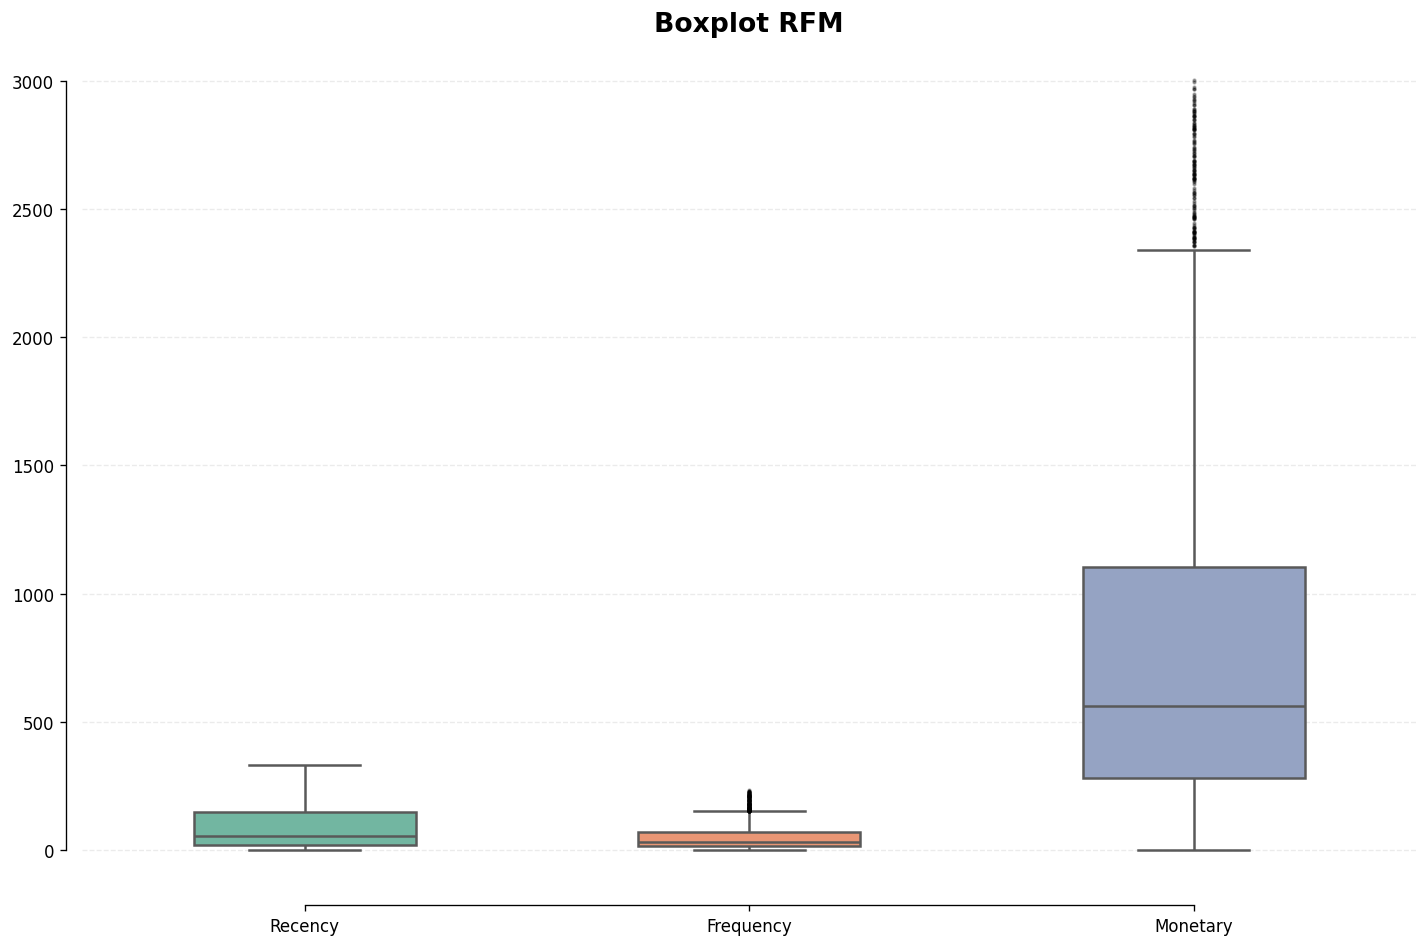

In [11]:
cols = ['Recency', 'Frequency', 'Monetary']
plt.figure(figsize=(12, 8))
ax = sns.boxplot(
    data=rfm[cols], palette=sns.color_palette("Set2", 3),
    width=0.5, linewidth=1.5,
    flierprops=dict(
        marker='.', markersize=3, alpha=0.3,
        markerfacecolor='black', markeredgecolor='black'
    )
)
ax.set_title("Boxplot RFM", fontsize=16, weight="bold")
sns.despine(offset=10, trim=True)
plt.tight_layout()
plt.show()

In [7]:
def handle_outlier(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    iqr = Q3 - Q1
    lower_bound = Q1 - 1.5 * iqr
    upper_bound = Q3 + 1.5 * iqr

    condition = (data[col] < lower_bound) | (data[col] > upper_bound)
    outlier = data[condition]
    print('Amount of Outlier:')
    print(outlier[col].count())

    no_outlier = data[~condition]

    return no_outlier.reset_index(drop=True)

rfm = handle_outlier(rfm, 'Recency')
rfm = handle_outlier(rfm, 'Frequency')
rfm = handle_outlier(rfm, 'Monetary')

Amount of Outlier:
149
Amount of Outlier:
373
Amount of Outlier:
313


## Pipeline for Feature Scaling and Dimensionality Reduction

In [8]:
cluster_cols = ['Recency', 'Frequency', 'Monetary']
X = rfm[cluster_cols].copy()

preprocessor = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=2, random_state=42))
    ]
)

X_scaled = pd.DataFrame(preprocessor.fit_transform(X), columns=['PCA_1', 'PCA_2'])

# Hopkins Testing
def hopkins(a):
    d = a.shape[1]
    n = a.shape[0]
    m = int(0.1 * n)

    nbrs = NearestNeighbors(n_neighbors=2).fit(a)
    rand_X = np.random.uniform(a.min(axis=0), a.max(axis=0), size=(m, d))

    ujd, wjd = [], []
    for j in range(m):
        u_dist, _ = nbrs.kneighbors(rand_X[j].reshape(1, -1 ), 1)
        ujd.append(u_dist[0][0])
        w_dist, _ = nbrs.kneighbors(a.iloc[np.random.randint(0, n)].values.reshape(1, -1), 2)
        wjd.append(w_dist[0][1])

    H = np.sum(ujd)/(np.sum(ujd) + np.sum(wjd))
    return H

for i in range(4):
    print('Hopkins statistic value is:', round(hopkins(X_scaled),3))

Hopkins statistic value is: 0.923
Hopkins statistic value is: 0.938
Hopkins statistic value is: 0.925
Hopkins statistic value is: 0.934


# Clustering

## Determine K Value

For n_clusters=2, the silhouette score is 0.4629056846042639
For n_clusters=3, the silhouette score is 0.5005507472794778
For n_clusters=4, the silhouette score is 0.4621465633299441
For n_clusters=5, the silhouette score is 0.4173355022855652
For n_clusters=6, the silhouette score is 0.4181349567374818
For n_clusters=7, the silhouette score is 0.4216409148281129
For n_clusters=8, the silhouette score is 0.3952940413573051
For n_clusters=9, the silhouette score is 0.39509298179464625
For n_clusters=10, the silhouette score is 0.35436572317589576
For n_clusters=11, the silhouette score is 0.35628441816062373



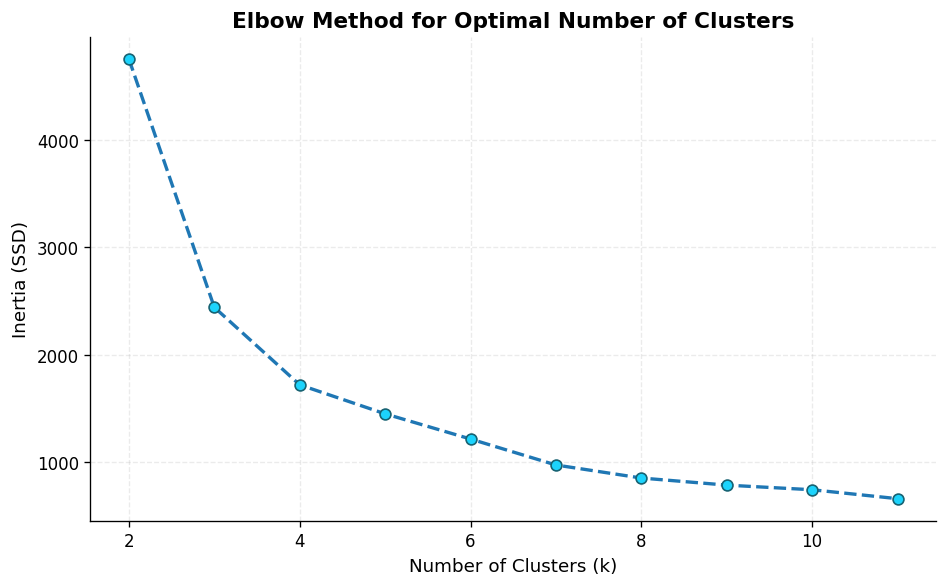

In [9]:
ssd, silhouette = [], []
range_of_k = [i for i in range(2, 12)]
for k in range_of_k:
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=50)
    kmeans.fit(X=X_scaled)
    ssd.append(kmeans.inertia_)
    silhouette_avg = silhouette_score(X=X_scaled, labels=kmeans.labels_)
    silhouette.append(silhouette_avg)

for i, value in enumerate(silhouette):
    print(f"For n_clusters={i + 2}, the silhouette score is {value}")
print()

plt.figure(figsize=(8, 5))
plt.plot(
    range_of_k, ssd,
    linewidth=2, linestyle='dashed',
    marker='.', markersize=13, markerfacecolor='#1CD3FC', markeredgecolor="#176272",
)

plt.xlabel("Number of Clusters (k)", fontsize=11)
plt.ylabel("Inertia (SSD)", fontsize=11)
plt.title("Elbow Method for Optimal Number of Clusters", fontsize=13, weight="bold")

plt.tight_layout()
plt.show()

## Fitting to KMeans

In [10]:
kmeans = KMeans(n_clusters=4, max_iter=50, random_state=42)
kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",50
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [12]:
X_scaled['cluster_id'] = kmeans.labels_
X['cluster_id'] = kmeans.labels_
rfm['cluster_id'] = kmeans.labels_

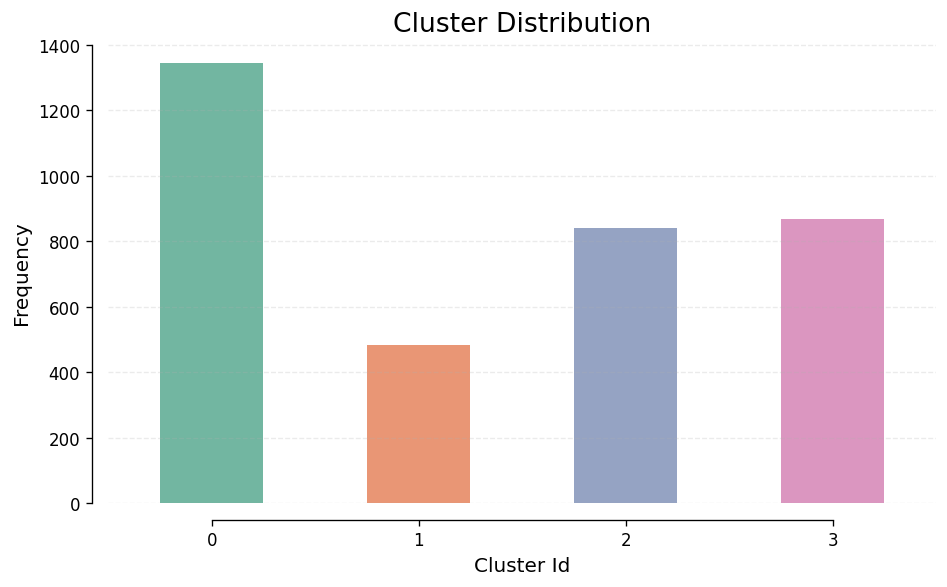

In [14]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    X_scaled['cluster_id'].value_counts(),
    width=0.5, linewidth=1,
    palette=sns.color_palette('Set2', 4)
)

ax.set_title('Cluster Distribution', fontsize=16, weight='normal')
ax.set_xlabel('Cluster Id', fontsize=12, weight='normal')
ax.set_ylabel('Frequency', fontsize=12, weight='normal')

sns.despine(offset=10, trim=True)
plt.tight_layout()
plt.show()

## Cluster Profiling using RFM

In [21]:
print(rfm.groupby('cluster_id').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}))

               Recency   Frequency     Monetary
cluster_id                                     
0            52.007435   23.844610   397.242076
1            37.585921  134.923395  1996.276128
2           234.100950   22.287411   381.269406
3            46.935409   69.494810  1124.465561


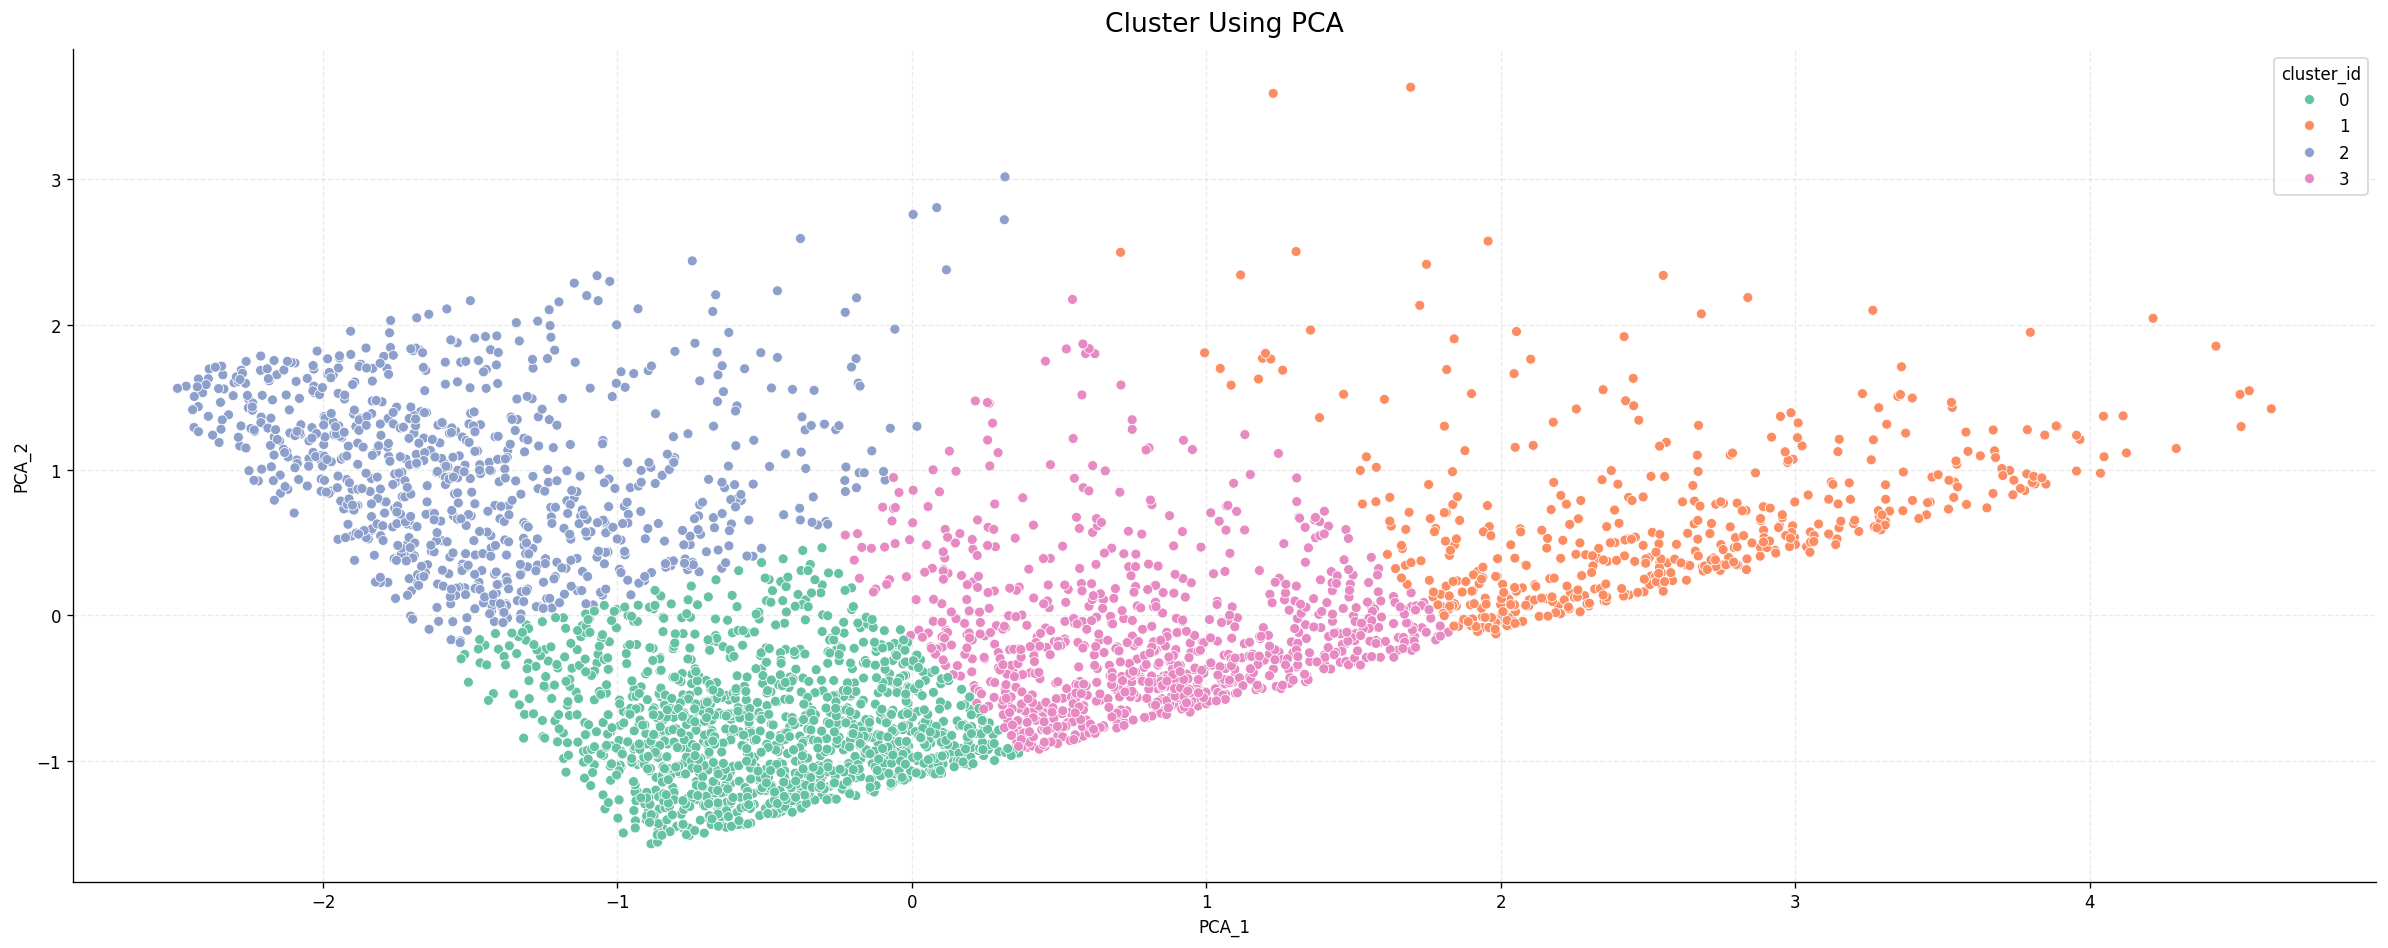

In [ ]:
plt.figure(figsize=(20, 8))
ax = sns.scatterplot(
    data=X_scaled, x='PCA_1', y='PCA_2',
    hue='cluster_id',
    palette=sns.color_palette('Set2', 4)
)
ax.set_title('Cluster Using PCA', fontsize=16, weight='normal')
plt.tight_layout()
plt.show()

**Inference:**

1. Cluster 0 has an average Recency of 52,1 days, Frequency of 23,84 transactions, and Monetary value of 397,24. These customers have made relatively recent purchases, but low purchase frequency and low total spending. These customers profile is **Low Value Customers**.

2. Cluster 1 has the most value among all segments, with Recency of 37,59 days, Frequency of 134,92 transactions, and Monetary value of 1996,28 total spend. These customer will be call **High Value Customers**.

3. Cluster 2 is negative correlation of Cluster 1, which is has the highest average Recency 234,1 days, and the lowest average Frequency and Monetary values. These customers are at high risk of churn and will be in **At Risk Customers** label.

4. Cluster 3 has an average Recency of 46.94 days, Frequency of 69.49 transactions, and Monetary value of 1,124.47, indicating that these customers active and contribute a considerable amount of revenue, although their purchasing behavior is less intensive than that of Cluster 1. These customers will be at **Reguler Customers** label.